In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from ultralytics import YOLO

sys.path.append("../src")
import failure_analysis as fa

fa.self_test()

MODEL_PATH = "../runs/runs/baseline_yolo11s_e100/runs/kaggle_yolo11s_optimized/weights/best.pt"
TEST_IMAGES_DIR = Path("../Anti-UAV-RGBT/yolo_dataset/images/test")
TEST_LABELS_DIR = Path("../Anti-UAV-RGBT/yolo_dataset/labels/test")
LABEL_NEW_PATH = Path("../Anti-UAV-RGBT/label_new/test.json")
ASSETS_DIR = Path("../assets")
ASSETS_DIR.mkdir(exist_ok=True)
RECORDS_CSV = ASSETS_DIR / "failure_analysis_records.csv"

model = YOLO(MODEL_PATH)
seq_attributes = fa.load_sequence_attributes(LABEL_NEW_PATH)
print(f"{len(seq_attributes)} tagged test sequences, "
      f"{len(list(TEST_IMAGES_DIR.glob('*.jpg')))} images in {TEST_IMAGES_DIR}")

self_test: OK
91 tagged test sequences, 15946 images in ../Anti-UAV-RGBT/yolo_dataset/images/test


## Section A

Виконує `best.pt` один раз для всіх ~16 тис. вибіркових кадрів тестового набору (`yolo_dataset/images/test`), зіставляє кожен прогноз з його базовим значенням у форматі YOLO та кешує таблицю результатів для кожного кадру в `assets/failure_analysis_records.csv`, тому повторний запуск цього блокнота не повторює повільний прохід виведення.

In [2]:
if RECORDS_CSV.exists():
    df = pd.read_csv(RECORDS_CSV)
    print(f"loaded cached records: {len(df)} rows from {RECORDS_CSV}")
else:
    records = []
    prev_gt_by_seq = {}
    for result in model.predict(
        source=str(TEST_IMAGES_DIR),
        stream=True,
        verbose=False,
        device="mps",
    ):
        filename = Path(result.path).name
        seq_id = fa.seq_id_from_filename(filename)
        frame_idx = fa.frame_index_from_filename(filename)
        img_h, img_w = result.orig_shape

        label_path = TEST_LABELS_DIR / (Path(filename).stem + ".txt")
        gt_box = fa.load_yolo_gt_box(label_path, img_w, img_h)
        pred_boxes = fa.pred_boxes_from_result(result)

        match = fa.match_frame(gt_box, pred_boxes)

        lr = fa.derive_lr(gt_box) if gt_box is not None else False
        prev_gt = prev_gt_by_seq.get(seq_id)
        fm, sv = fa.derive_fm_sv(prev_gt, gt_box)
        prev_gt_by_seq[seq_id] = gt_box

        best_conf = max((c for _, c in pred_boxes), default=0.0)
        records.append({
            "filename": filename,
            "seq_id": seq_id,
            "frame_idx": frame_idx,
            "outcome": match.outcome,
            "iou": match.iou,
            "best_conf": best_conf,
            "gt_present": gt_box is not None,
            "lr": lr,
            "fm": fm,
            "sv": sv,
        })

    df = pd.DataFrame(records)
    df.to_csv(RECORDS_CSV, index=False)
    print(f"ran inference on {len(df)} images, cached to {RECORDS_CSV}")

df["outcome"].value_counts()

loaded cached records: 15946 rows from ../assets/failure_analysis_records.csv


outcome
TP    12903
FN     1884
TN     1007
FP      152
Name: count, dtype: int64

## Section B

Групує результати для кожного кадру за офіційними атрибутами завдання Anti-UAV (`label_new/test.json`, теги рівня послідовності: `OV, OC, FM, SV, LI, TC, LR`) та обчислює точність/повність/F1/середнє значення IoU для кожного атрибута поруч із базовим рядком «загального» — такої ж форми, як Таблиця III у статті Anti-UAV. 

Стовпці `FM`/`SV` у `df` є вторинним, приблизним сигналом для кожного кадру (див. застереження під таблицею); `LR` є точним (на основі області, суміжність не потрібна). У таблиці нижче групується за **офіційними тегами рівня послідовності**, що є первинною віссю зіставлення DoD.


In [3]:
attr_table = fa.attribute_metrics_table(df, seq_attributes)

attr_table_display = attr_table.copy()
for col in ["precision", "recall", "f1", "mean_iou"]:
    attr_table_display[col] = (attr_table_display[col] * 100).round(1)
attr_table_display["n_frames"] = attr_table_display["n_frames"].astype(int)
attr_table_display

,n_frames,precision,recall,f1,mean_iou
overall,15946,98.8,87.3,92.7,68.1
FM,6085,97.6,90.2,93.8,70.4
LI,3541,97.5,98.3,97.9,76.3
LR,2971,98.6,92.9,95.7,70.7
OC,578,93.9,98.1,96.0,71.6
OV,4014,95.3,94.8,95.0,73.9
SV,3707,97.9,81.9,89.2,63.1
TC,10934,99.3,82.1,89.9,64.0


In [4]:
overall_recall = attr_table.loc["overall", "recall"]
overall_iou = attr_table.loc["overall", "mean_iou"]
degradation = (attr_table.drop("overall")["recall"] - overall_recall).sort_values()

print("Recall degradation vs. overall baseline (most negative = worst attribute):")
print((degradation * 100).round(1).to_string())
print(f"\noverall recall={overall_recall * 100:.1f}%, overall mean IoU={overall_iou * 100:.1f}%")

Recall degradation vs. overall baseline (most negative = worst attribute):
SV    -5.3
TC    -5.1
FM     3.0
LR     5.6
OV     7.5
OC    10.8
LI    11.0

overall recall=87.3%, overall mean IoU=68.1%


**Застереження щодо `FM`/`SV`:** обчислені на семплованих кадрах (крок ~5–50
кадрів між сусідніми елементами `yolo_dataset/images/test`, а не на справжніх
сусідніх кадрах 25 FPS відео), тож зсув/зміна масштабу між ними систематично
завищені відносно офіційного означення (яке передбачає суміжні кадри
відеопотоку). 

`LR` — точний, бо не залежить від сусідніх кадрів. Основний
розріз метрик у таблиці вище — за офіційними тегами `label_new`, що відповідає
гранулярності самої статті (по послідовностях, не по кадрах).

## Section C 

Найгірші хибнонегативні та хибнопозитивні кадри. Поле GT зелене, прогноз моделі червоне. Кожна зона має підпис з ідентифікатором послідовності, її офіційними тегами атрибутів та IO/впевненість.

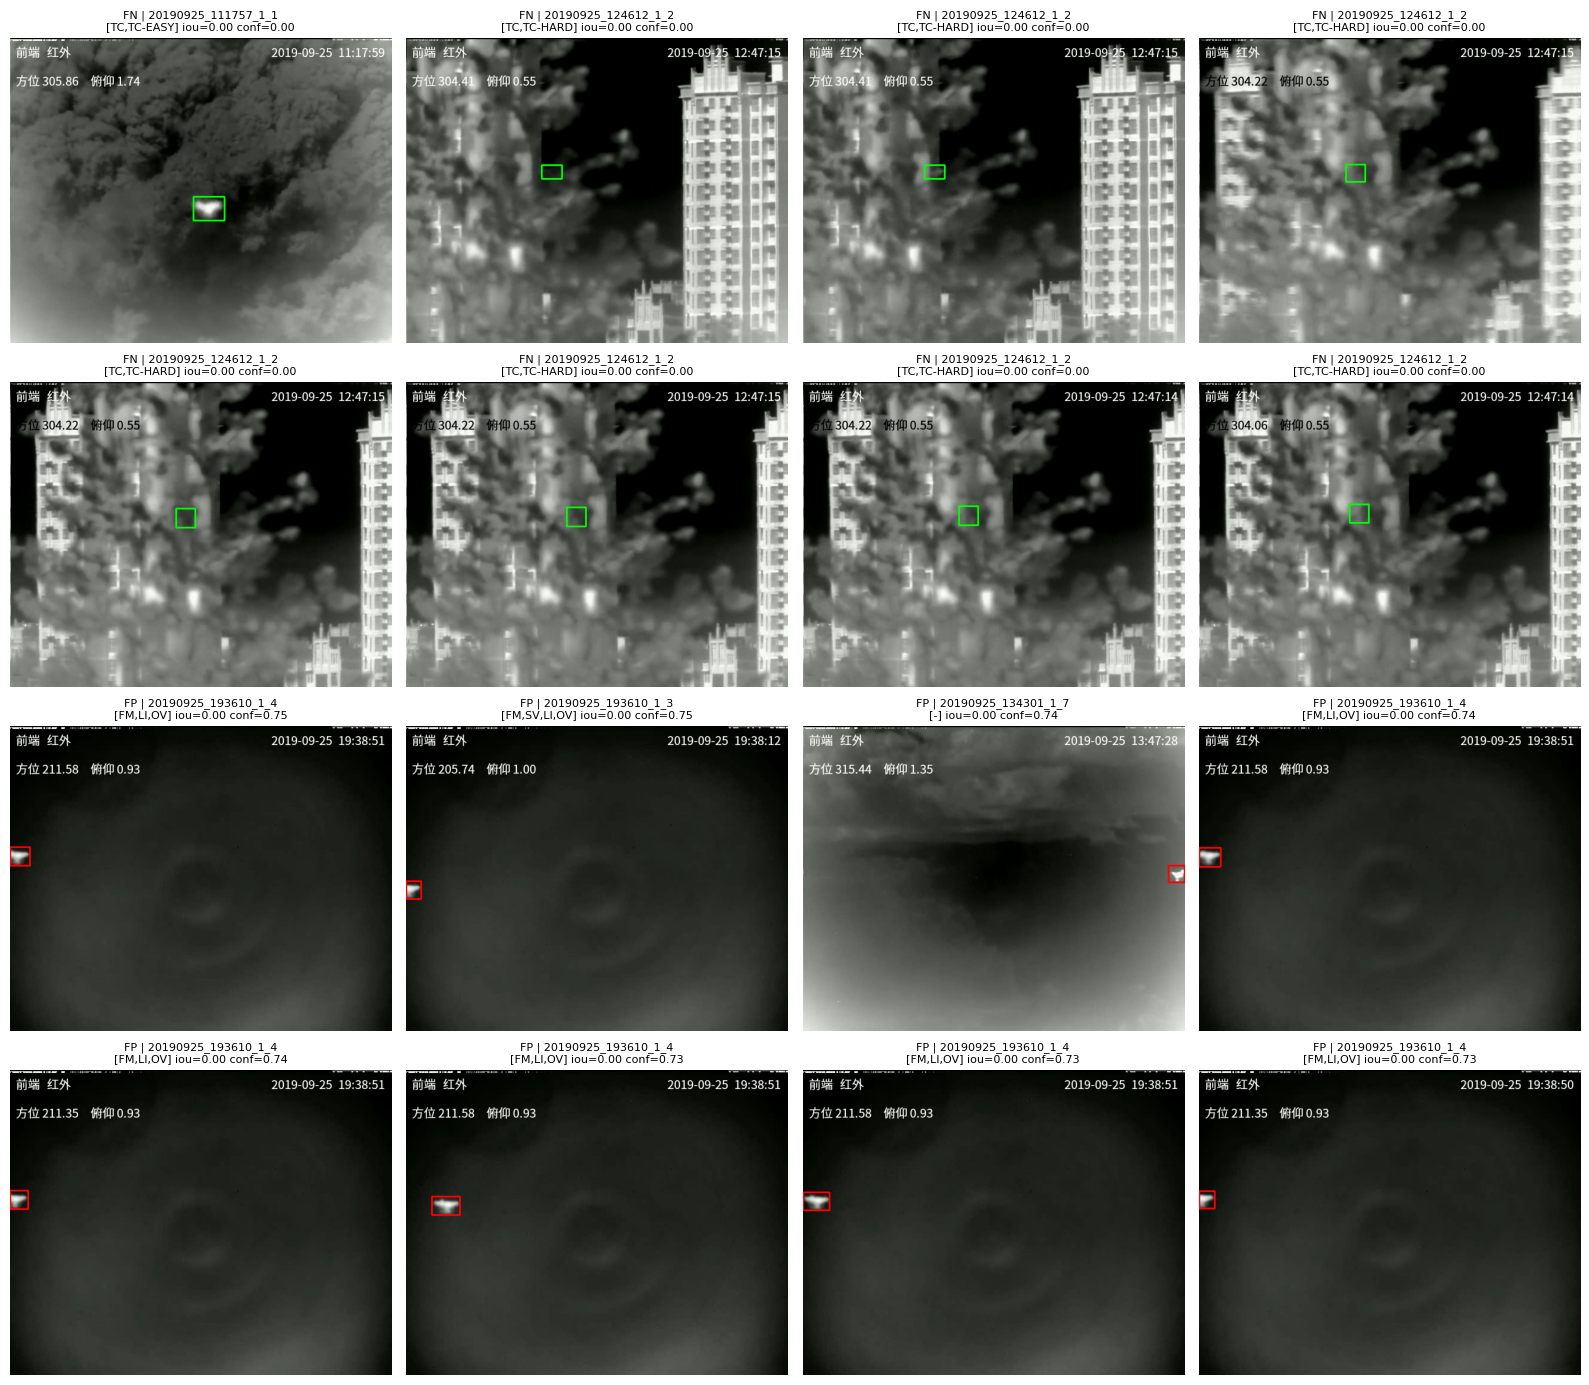

saved ../assets/failure_gallery.png


In [5]:
import cv2
import matplotlib.pyplot as plt

N_PER_CLASS = 8

fn_worst = df[df["outcome"] == "FN"].sort_values("iou").head(N_PER_CLASS)
fp_worst = df[df["outcome"] == "FP"].sort_values("best_conf", ascending=False).head(N_PER_CLASS)
gallery_rows = [("FN", r) for _, r in fn_worst.iterrows()] + [("FP", r) for _, r in fp_worst.iterrows()]

n = len(gallery_rows)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (kind, row) in zip(axes, gallery_rows):
    img_path = TEST_IMAGES_DIR / row["filename"]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]

    label_path = TEST_LABELS_DIR / (Path(row["filename"]).stem + ".txt")
    gt_box = fa.load_yolo_gt_box(label_path, img_w, img_h)
    if gt_box is not None:
        x, y, w, h = (int(v) for v in gt_box)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    result = model.predict(str(img_path), verbose=False, device="mps")[0]
    for box_xywh, conf in fa.pred_boxes_from_result(result):
        x, y, w, h = (int(v) for v in box_xywh)
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    tags = ",".join(seq_attributes.get(row["seq_id"], [])) or "-"
    ax.imshow(img)
    ax.set_title(
        f"{kind} | {row['seq_id']}\n[{tags}] iou={row['iou']:.2f} conf={row['best_conf']:.2f}",
        fontsize=8,
    )
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(ASSETS_DIR / "failure_gallery.png", dpi=120)
plt.show()
print(f"saved {ASSETS_DIR / 'failure_gallery.png'}")

## Section D — Висновки

Числа із Section B (15 946 тестових кадрів, `overall`: precision 98.8%, recall 87.3%, mean IoU 68.1%):

- **Це майже виключно проблема пропусків (recall).** Precision
  тримається на рівні 93.9–99.3% для *кожного* атрибута, а FP всього 152 з
  15 946 кадрів (~1%). Модель рідко "бачить дрон там, де його немає" — вона
  здебільшого його просто не знаходить.
- **91.4% (139/152) усіх FP належать послідовностям із тегом OV (Out-of-View).**
  Візуальний огляд галереї в Section C підтверджує чому: у цих кадрах GT
  промічений як "цілі немає", але на зображенні видно яскраву теплову пляму
  дрона в кутку кадру — модель коректно її виявляє з високою впевненістю
  (conf 0.73–0.75), а "помилка" — це фактично межовий випадок розмітки на
  вході/виході дрона з кадру, а не хибне спрацювання на випадковому фоні.
  Отже, з 152 FP більшість — не справжні галюцинації детектора.
- **Два виміряно найгірші атрибути за recall — SV (Scale Variation, −5.3 в.п.
  від overall) і TC (Thermal Crossover, −5.1 в.п.).** Вони ж мають і найнижчий
  mean IoU серед усіх атрибутів (63.1% та 64.0% відповідно) — тобто навіть
  вдалі детекції на цих кадрах локалізовані менш точно.
  - **SV-гіпотеза:** різка зміна масштабу цілі (дрон швидко наближається/
    віддаляється) виводить об'єкт за межі масштабного діапазону, на якому
    детектор впевнено навчився — звідси і нижчий IoU, і пропуски.
  - **TC-гіпотеза:** теплова сигнатура цілі зливається з фоном на ІЧ-кадрі —
    обмеження інфрачервоного сенсора. Галерея в Section C це підтверджує
    візуально (FN-приклади з тегом TC — дрон практично невідрізнимий від
    хмар/будівлі на око).
- **Контрінтуїтивний результат:** LR/OC/OV/LI показують recall *вищий* за
  overall, хоча інтуїтивно очікувалось навпаки (особливо для OC — оклюзії).
  Причина, ймовірно, методологічна: теги `label_new` — на рівні послідовності,
  а не кадру. Послідовність, позначена "OC", може мати лише кілька кадрів із
  реальною оклюзією серед сотень "простих" кадрів — агрегована метрика по
  атрибуту розмивається цими простими кадрами. Це відома межа наближення
  (сама специфікація завдання це визнає: атрибути в `label_new` — послідовностні,
  не покадрові) і напрям для покращення — власна per-frame розмітка occlusion
  дала б чистіший сигнал.

## mSA (mean State Accuracy) на всіх 91 тестових послідовностях

Всього ~85 тис. кадрів (91 відео × ~1000 кадрів) — кешується в `assets/msa_per_sequence.csv`.

In [6]:
MSA_CSV = ASSETS_DIR / "msa_per_sequence.csv"
TEST_ROOT = Path("../Anti-UAV-RGBT/test")

if MSA_CSV.exists():
    sa_df = pd.read_csv(MSA_CSV)
    print(f"loaded cached mSA: {len(sa_df)} sequences from {MSA_CSV}")
else:
    seq_dirs = sorted(p for p in TEST_ROOT.iterdir() if p.is_dir())
    rows = []
    for i, seq_dir in enumerate(seq_dirs):
        seq_id = seq_dir.name
        gt_path = seq_dir / "infrared.json"
        video_path = seq_dir / "infrared.mp4"
        if not gt_path.exists() or not video_path.exists():
            continue

        with open(gt_path) as f:
            gt = json.load(f)
        gt_exist, gt_rect = gt["exist"], gt["gt_rect"]

        frame_preds = [
            fa.pred_boxes_from_result(result)
            for result in model.predict(source=str(video_path), stream=True, verbose=False, device="mps")
        ]

        if len(frame_preds) != len(gt_exist):
            n = min(len(frame_preds), len(gt_exist))
            print(f"WARNING: {seq_id} frame count mismatch: {len(frame_preds)} pred vs {len(gt_exist)} gt, truncating to {n}")
            frame_preds, gt_exist_i, gt_rect_i = frame_preds[:n], gt_exist[:n], gt_rect[:n]
        else:
            gt_exist_i, gt_rect_i = gt_exist, gt_rect

        sa = fa.state_accuracy(gt_exist_i, gt_rect_i, frame_preds)
        rows.append({
            "seq_id": seq_id,
            "n_frames": len(gt_exist_i),
            "sa": sa,
            "tags": ",".join(seq_attributes.get(seq_id, [])),
        })
        print(f"[{i + 1}/{len(seq_dirs)}] {seq_id}: SA={sa:.4f}")

    sa_df = pd.DataFrame(rows)
    sa_df.to_csv(MSA_CSV, index=False)
    print(f"saved {MSA_CSV}")

mSA = sa_df["sa"].mean()
print(f"\nmSA over {len(sa_df)} test sequences: {mSA:.4f} ({mSA * 100:.1f}%)")

[1/91] 20190925_111757_1_1: SA=0.0457


[2/91] 20190925_111757_1_10: SA=0.9143


[3/91] 20190925_111757_1_2: SA=0.1300


[4/91] 20190925_111757_1_3: SA=0.6639


[5/91] 20190925_111757_1_4: SA=0.7158


...

[87/91] 20190926_134054_1_5: SA=0.7731


[88/91] 20190926_134054_1_6: SA=0.7891


[89/91] 20190926_134054_1_7: SA=0.8111


[90/91] 20190926_134054_1_8: SA=0.7997


[91/91] 20190926_134054_1_9: SA=0.7601
saved ../assets/msa_per_sequence.csv

mSA over 91 test sequences: 0.6357 (63.6%)


In [ ]:
# 10 найгірших послідовностей за SA
sa_df.sort_values("sa").head(10)

,seq_id,n_frames,sa,tags
17,20190925_124000_1_7,1000,-0.023794,"FM,TC,TC-HARD"
6,20190925_111757_1_6,1000,-0.010712,"TC,TC-HARD"
0,20190925_111757_1_1,1000,0.045743,"TC,TC-EASY"
18,20190925_124000_1_8,1000,0.050214,"TC,TC-HARD"
15,20190925_124000_1_5,1000,0.110259,"TC,TC-HARD"
2,20190925_111757_1_2,1000,0.130016,"FM,SV,TC,TC-MID"
22,20190925_124612_1_3,1000,0.132089,"SV,TC,OV,TC-HARD"
24,20190925_124612_1_5,1000,0.136545,"TC,TC-MID"
19,20190925_124000_1_9,1000,0.236001,"TC,TC-HARD"
21,20190925_124612_1_2,1000,0.285814,"TC,TC-HARD"


**mSA = 63.6% по всіх 91 послідовностях**. 
Усі 10 найгірших послідовностей за SA позначені тегом **TC** (7 з 10 — саме
`TC-HARD`), що незалежно підтверджує висновок Section D: thermal crossover —
головний фактор провалу, видимий одразу в двох різних метриках (frame-level
detection recall у Section B і sequence-level tracking SA тут).

## Section E — Порівняння з опублікованими baseline

In [8]:
published_msa = pd.DataFrame([
    {"tracker": "SiamFC", "mSA_IR_%": 11.02, "mSA_Visible_%": 31.60},
    {"tracker": "MDNet", "mSA_IR_%": 15.44, "mSA_Visible_%": 39.79},
    {"tracker": "ECO-HC", "mSA_IR_%": 14.76, "mSA_Visible_%": 41.91},
    {"tracker": "SiamRPN++", "mSA_IR_%": 16.46, "mSA_Visible_%": 41.21},
    {"tracker": "Ours (YOLO11s, 91 test sequences)", "mSA_IR_%": round(mSA * 100, 2), "mSA_Visible_%": None},
]).set_index("tracker")
published_msa

,mSA_IR_%,mSA_Visible_%
tracker,,
SiamFC,11.02,31.60
MDNet,15.44,39.79
ECO-HC,14.76,41.91
SiamRPN++,16.46,41.21
"Ours (YOLO11s, 91 test sequences)",63.57,NaN


**Джерело:** Jiang et al., *"Anti-UAV: A Large Multi-Modal Benchmark for UAV Tracking"*,
arXiv:2101.08466, Table IV (evaluation Protocol I, test split, метрика mSA %).

**Застереження — це не рівнозначні порівняння:**
- Published-трекери оцінені за **Protocol I**: zero-shot Single Object Tracking,
  ініціалізація лише першим кадром GT-боксу, без тренування на Anti-UAV.
- Наш пайплайн тренується на даних Anti-UAV (**Protocol II**) — детектор
  (YOLO11s, per-frame, без ініціалізації GT-боксом), а не класичний SOT.
  Число вище — чиста детекція (`model.predict`, без ByteTrack), оскільки
  формула mSA не залежить від ідентичності треку, лише від присутності й IoU
  найкращого боксу на кадрі; ByteTrack-версія на одному відео дала
  дуже близький результат (74.4%), що й очікувано з цієї причини.
- Висновок: різниця в ~4–7× очікувана і пояснюється відмінністю постановок
  (навчена на домені детекція проти zero-shot SOT з ініціалізацією GT-боксом)